# Yield Distributions

Until now we assumed every unit ordered is sellable. In reality many production processes have uncertain **yield** — the fraction of ordered units that pass quality control.

**Examples:**
- A bakery oven with uneven heat: some muffins come out under-baked or burnt
- A circuit board manufacturer: a share of boards fail electrical testing
- A fresh produce supplier: some fraction arrives bruised or spoiled

Yield introduces a **second source of uncertainty** alongside demand. The effective supply per scenario is:

$$Q_{\text{eff}} = Q \cdot Y, \quad Y \sim \text{Beta}(\alpha, \beta)$$

where $Q$ is the order quantity and $Y \in [0, 1]$ is the random yield rate. The **Beta distribution** is the natural choice because its support exactly matches a proportion, and $\alpha$, $\beta$ directly control the mean and spread.

### Choosing Beta parameters

| `BetaYield(α, β)` | Mean yield | Spread | Represents |
|---|---|---|---|
| Beta(18, 2) | 90% | Low | Automated process, rare defects |
| Beta(8, 2) | 80% | Moderate | Standard production line |
| Beta(3, 2) | 60% | High | Manual / inconsistent process |
| Beta(1, 4) | 20% | High | Early-stage / artisan process |

**Key implication:** to expect $D$ sellable units when yield averages $\bar{Y}$, you must order roughly $D / \bar{Y}$ units. But because $Y$ is *random*, the true safe-stock quantity is higher still — especially when both demand and yield can disappoint simultaneously.

### Example scenario

Our bakery has two products on **different equipment**:
- **Plain muffin** — baked in an old gas oven. High average demand but unreliable yield (~60%, `Beta(3, 2)`).
- **Chocolate muffin** — made with a modern machine. Steadier demand and reliable yield (~90%, `Beta(18, 2)`).

Shared resources: a total **ingredient budget** and a fixed amount of daily **oven time**.

In [12]:
import numpy as np
import xarray as xr

from optistock.items import Item
from optistock.distributions.demand_distributions import NormalDemand
from optistock.distributions.yield_distributions import BetaYield
from optistock.solvers import ForecastSolver


class DistributionForecaster:
    """
    Thin adapter that wraps a DemandDistribution for use with ForecastSolver.
    Generates Monte Carlo demand samples on each call to get_demand_distribution.
    (See notebook 2 for a full explanation of this adapter.)
    """

    def __init__(self, distribution, n_samples: int = 2000):
        self.distribution = distribution
        self.n_samples = n_samples

    def get_demand_distribution(self, start_date, end_date):
        samples = np.maximum(
            0,
            np.random.normal(
                self.distribution.mean, self.distribution.std, self.n_samples
            ),
        )
        return xr.Dataset({"demand": ("sample", samples)})


# ── Items ─────────────────────────────────────────────────────────────────────
# yield_distribution is sampled per scenario inside the solver:
#   effective_supply = order_quantity × yield_sample
plain_muffin = Item(
    "plain muffin",
    cost_price=8,
    selling_price=20,
    salvage_value=2,
    constraints={"ingredient_cost": 8, "oven_time": 1},
    yield_distribution=BetaYield(3, 2),   # mean ≈ 60 %, high variance — old oven
)
chocolate_muffin = Item(
    "chocolate muffin",
    cost_price=12,
    selling_price=28,
    salvage_value=4,
    constraints={"ingredient_cost": 12, "oven_time": 2},
    yield_distribution=BetaYield(18, 2),  # mean ≈ 90 %, low variance — new machine
)

# ── Demand distributions ──────────────────────────────────────────────────────
plain_demand     = NormalDemand(100, 20)
chocolate_demand = NormalDemand(80, 15)

# ── Shared resource limits ────────────────────────────────────────────────────
LIMITS = {"ingredient_cost": 3_000, "oven_time": 400}

# ForecastSolver needs forecasters; plotting functions need DemandDistribution
solver_problems = [
    (plain_muffin,     DistributionForecaster(plain_demand)),
    (chocolate_muffin, DistributionForecaster(chocolate_demand)),
]
plot_problems = [
    (plain_muffin,     plain_demand),
    (chocolate_muffin, chocolate_demand),
]

# ── Strategy 1: SAA — maximise E[profit], ignores tail risk ──────────────────
solver_saa = ForecastSolver(solver_problems, limits=LIMITS, objective="SAA")
res_saa = solver_saa.solve("2025-01-01", "2025-01-02")

# ── Strategy 2: CVaR — protect the worst 10 % of scenarios ───────────────────
# cvar_lambda=0.7 puts 70 % weight on tail protection, 30 % on mean profit.
# With two stochastic sources (demand + yield), this alpha captures scenarios
# where both yield and demand are simultaneously unfavourable.
solver_cvar = ForecastSolver(
    solver_problems, limits=LIMITS,
    objective="CVaR", cvar_alpha=0.10, cvar_lambda=0.7,
)
res_cvar = solver_cvar.solve("2025-01-01", "2025-01-02")

# ── Strategy 3: Utility — smooth exponential risk aversion ────────────────────
# risk_aversion=0.4 maps to ρ = σ_profit × 0.6/0.4 = 1.5σ. Penalises
# downside scenarios continuously rather than focusing only on the tail.
solver_util = ForecastSolver(
    solver_problems, limits=LIMITS,
    objective="Utility", risk_aversion=0.01
)
res_util = solver_util.solve("2025-01-01", "2025-01-02")

# ── Compare allocations ───────────────────────────────────────────────────────
print(f"{'Strategy':<20} {'Plain muffin':>14} {'Chocolate muffin':>18}")
print("-" * 55)
for label, res in [("SAA", res_saa), ("CVaR", res_cvar), ("Utility", res_util)]:
    print(f"{label:<20} {res['plain muffin']:>14} {res['chocolate muffin']:>18}")

Strategy               Plain muffin   Chocolate muffin
-------------------------------------------------------
SAA                             132                 93
CVaR                             77                 85
Utility                           1                 25


## Reading the Allocation Table

Notice how the order quantities differ across strategies — particularly for the **plain muffin** with its unreliable yield.

- The **SAA** strategy orders enough to maximise average profit, implicitly assuming that good and bad yield days average out.
- The **CVaR** strategy focuses on the worst 10 % of combined demand+yield scenarios. Because the plain muffin's old oven can produce as few as 30–40 % good units on a bad day, CVaR adjusts the quantity to keep the tail profit acceptable.
- The **Utility** strategy penalises all downside scenarios smoothly via the exponential function, producing a result between the two extremes.

The **chocolate muffin** (reliable yield, Beta(18,2)) changes less between strategies — when yield is predictable, the risk adjustment is smaller.

Below we visualise the CVaR allocation against the resource constraints.

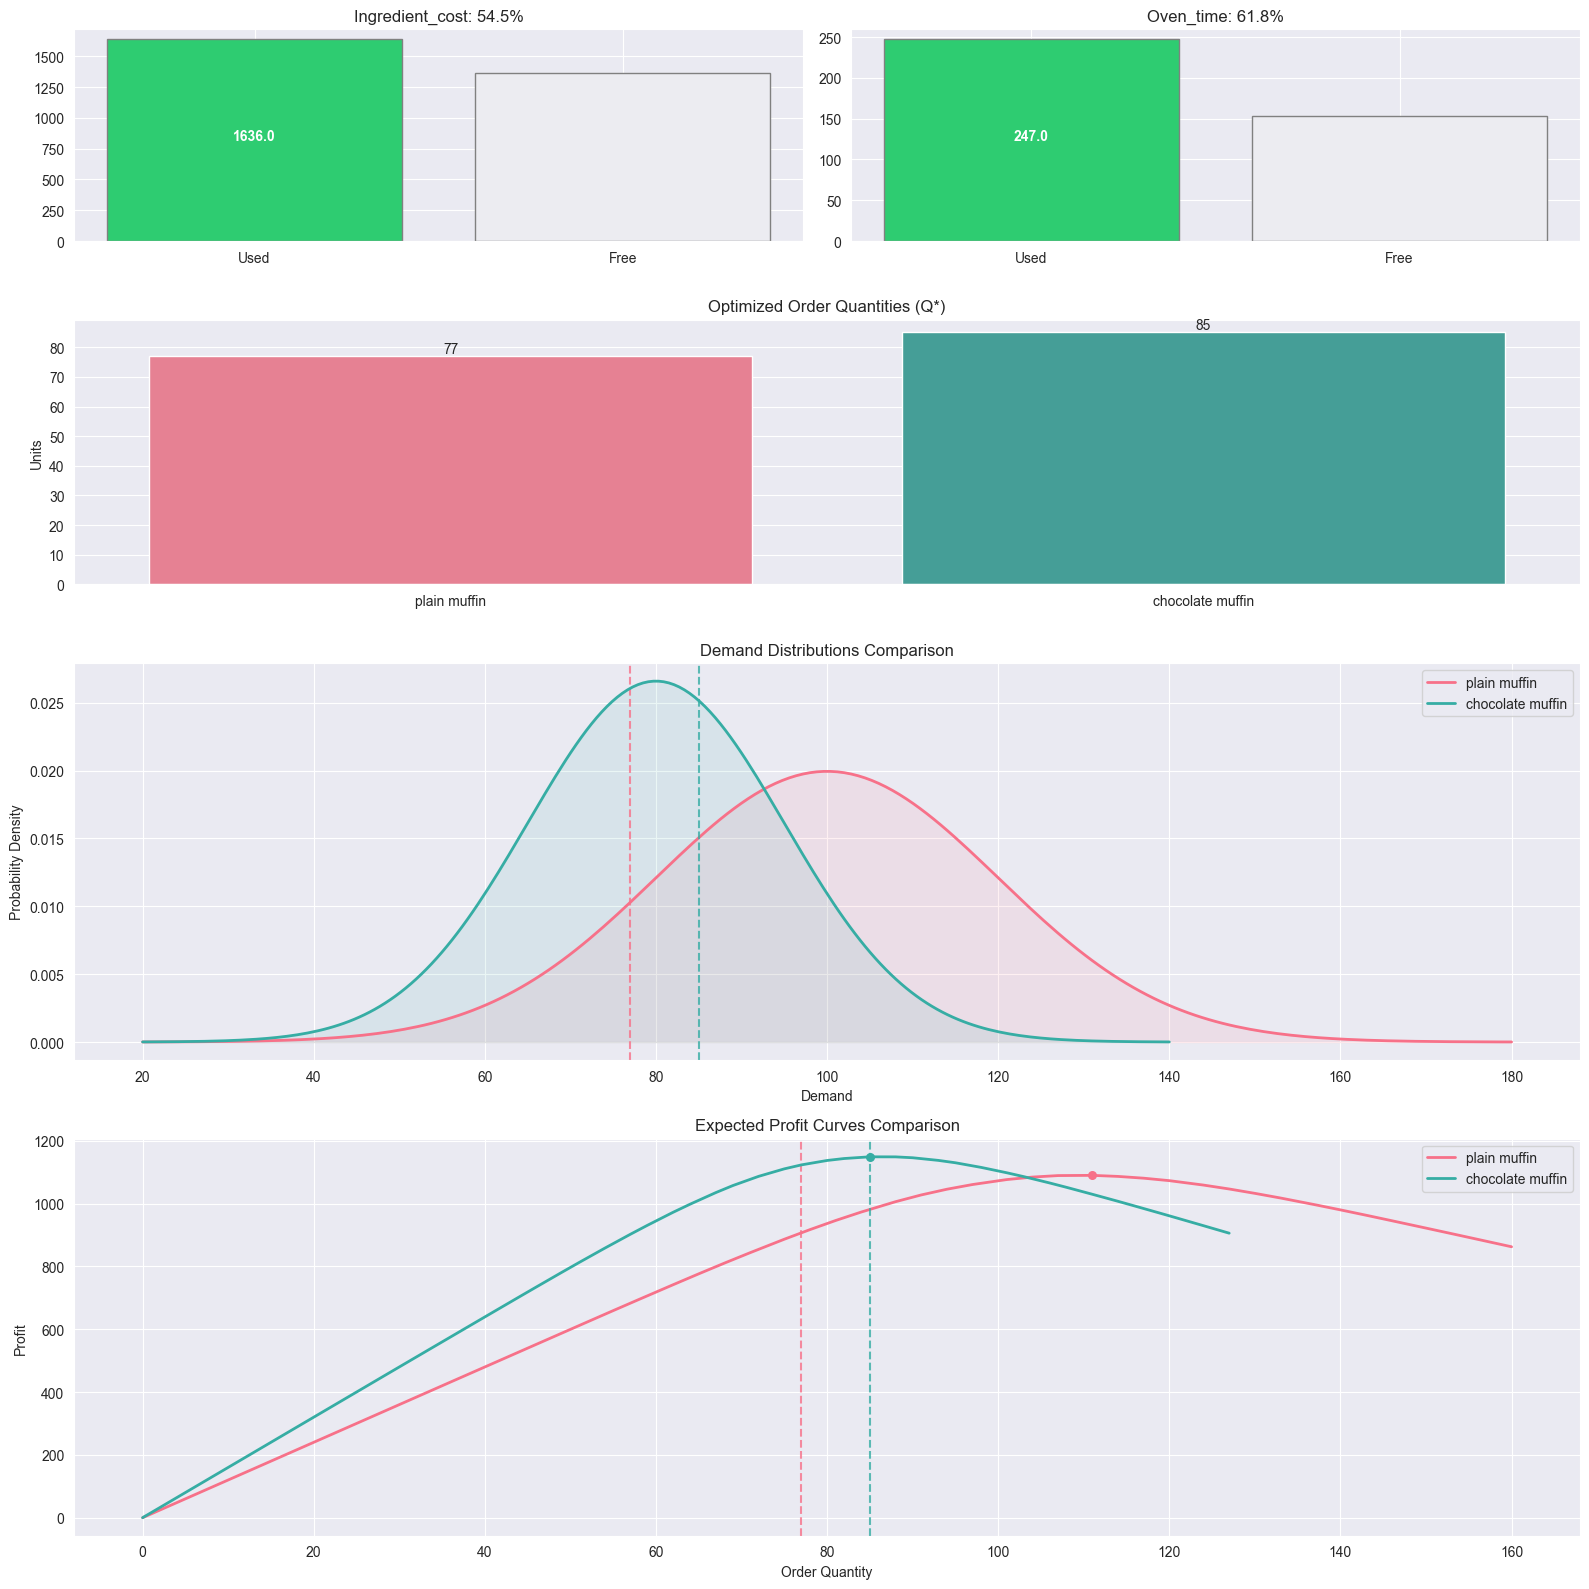

In [13]:
from optistock.plot_suite.portfolio import plot_constrained_allocation

# Visualise the CVaR allocation against both resource constraints.
# Note: demand curves shown here are the raw NormalDemand distributions,
# not the effective yield-adjusted supply — that nuance is captured inside
# the solver but not in this particular plot.
fig = plot_constrained_allocation(res_cvar, plot_problems, LIMITS)

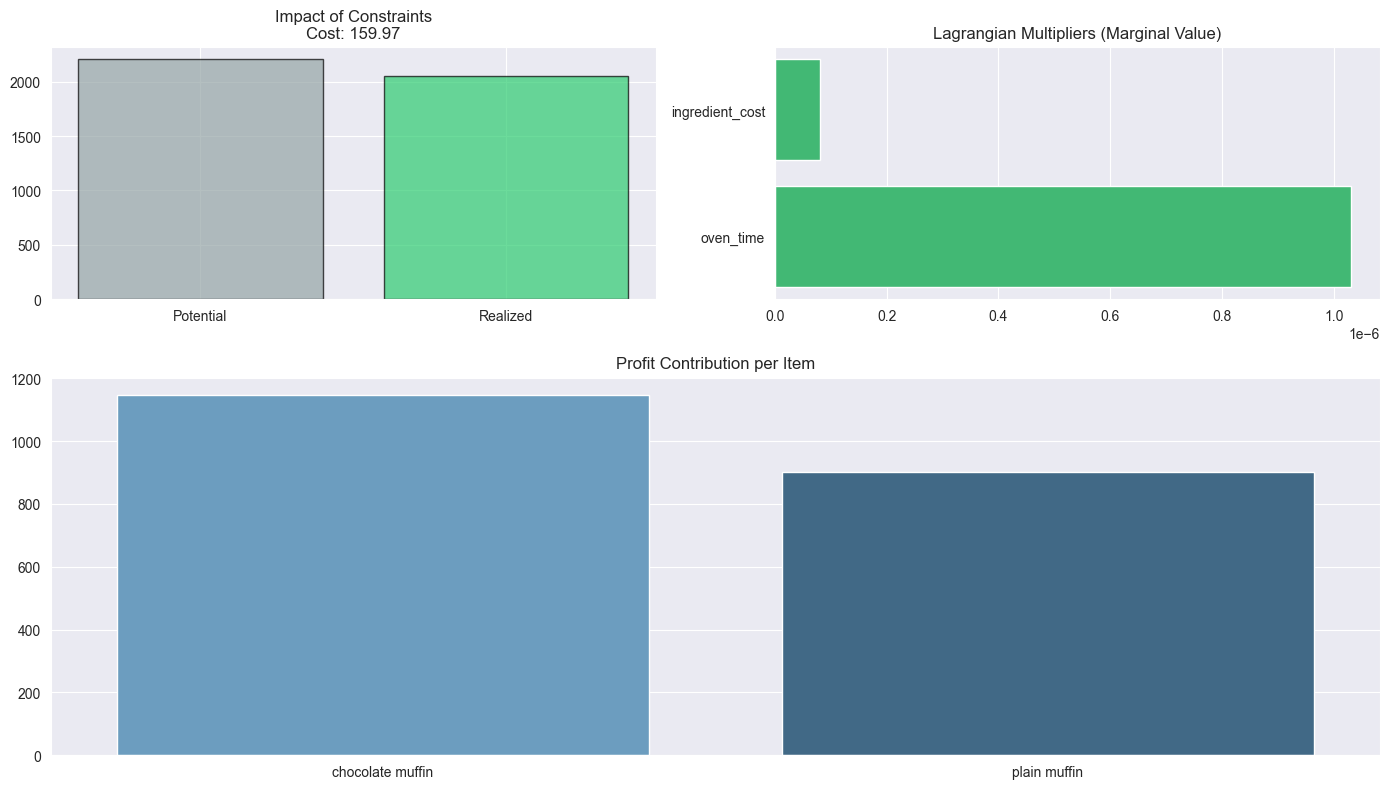

In [14]:
from optistock.plot_suite.portfolio import plot_optimization_summary

# shadow_prices holds the Lagrangian multipliers from the trust-region solver.
# A high shadow price on "oven_time" means adding one more oven-hour would
# increase expected (CVaR-adjusted) profit by that amount.
# Note: the "Potential" bar assumes perfect yield for the unconstrained optimum,
# so it slightly overstates the true gap. The shadow prices are still accurate.
fig = plot_optimization_summary(res_cvar, plot_problems, solver_cvar.shadow_prices)

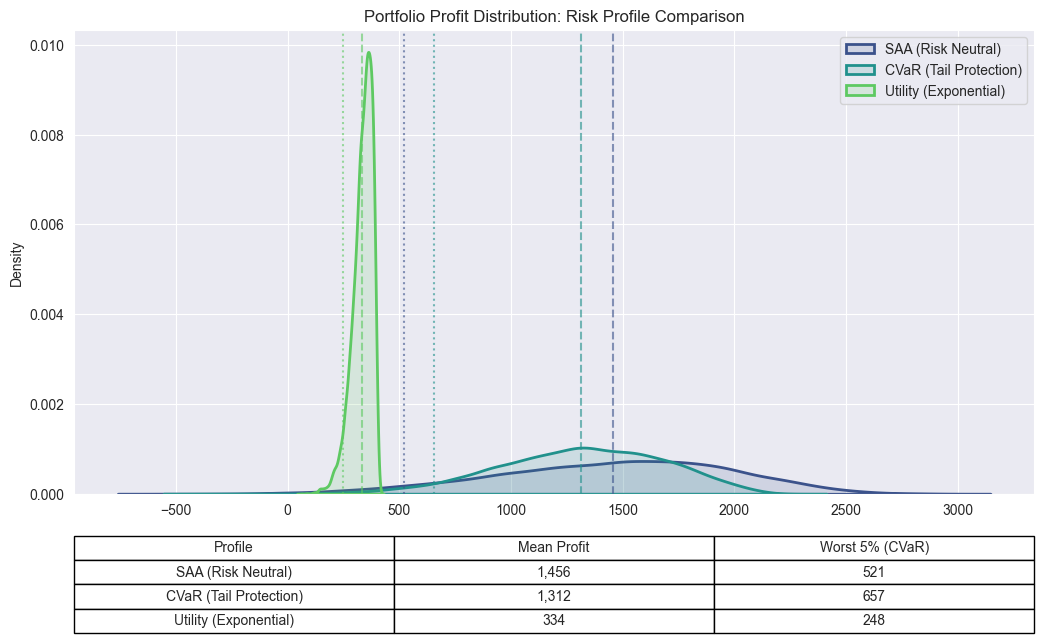

In [15]:
from optistock.plot_suite.risk import plot_risk_comparison

# Overlay the simulated profit distributions for all three strategies.
# The dashed line marks the mean profit; the dotted line marks the worst-5% (CVaR).
# Each distribution is simulated using the item's yield_distribution, so the
# spread you see reflects both demand uncertainty AND yield uncertainty.
fig = plot_risk_comparison(
    {
        "SAA (Risk Neutral)":     res_saa,
        "CVaR (Tail Protection)": res_cvar,
        "Utility (Exponential)":  res_util,
    },
    problems=plot_problems,
)

## Interpreting the Risk Profiles

The profit distribution plot shows the fundamental trade-off between the three objectives:

- **SAA** maximises mean profit. It allocates based on average yield and average demand, accepting that bad days will be bad. The distribution tends to be widest — highest peak but longest left tail.

- **CVaR** specifically guards the worst 10 % of scenarios (`cvar_alpha=0.10`). The `cvar_lambda=0.7` parameter puts 70 % weight on tail protection. Compared to SAA, the CVaR distribution typically has a shorter left tail at the cost of a slightly lower mean.

- **Utility (Exponential)** penalises downside scenarios continuously via $U(x) = -e^{-x/\rho}$. At `risk_aversion=0.4`, the internal scale is $\rho = 1.5\,\sigma_{\text{profit}}$. The resulting allocation sits between SAA and CVaR.

### When does yield uncertainty dominate?

Compare how much the strategies diverge for the **plain muffin** (unreliable, Beta(3,2)) vs the **chocolate muffin** (reliable, Beta(18,2)):

- With high yield variance, a bad yield day *compounds* a bad demand day. Risk-averse objectives respond by adjusting the order quantity to hedge against this joint downside.
- With low yield variance, the effective supply is nearly deterministic given $Q$, so the risk strategies converge toward SAA.

### Business guidance

| Question | Answer |
|---|---|
| "Which constraint is worth relaxing?" | Shadow price — the highest value constraint gives the most profit per extra unit of resource |
| "How bad can a bad day get?" | CVaR worst-5% in the table below the risk comparison plot |
| "Should I invest in better equipment?" | Compare the improvement in CVaR profit between `BetaYield(3, 2)` and `BetaYield(15, 2)` for the plain muffin |